<a href="https://colab.research.google.com/github/itsmeJoel18/ml_project_compilation/blob/main/Calderon_ml_activity_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [61]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [18]:
path=kagglehub.dataset_download("larsen0966/student-performance-data-set")
print("path to the dataset files: ", path)

100%|██████████| 12.1k/12.1k [00:00<00:00, 17.0MB/s]

Extracting files...
path to the dataset files:  /root/.cache/kagglehub/datasets/larsen0966/student-performance-data-set/versions/2


In [ ]:
print(os.listdir(path))

['student-mat.csv']


In [29]:
file_path=os.path.join(path,"student-por.csv")
df=pd.read_csv(file_path, sep=",")

In [16]:
df.head()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0,"GP;""F"";18;""U"";""GT3"";""A"";4;4;""at_home"";""teacher..."
1,"GP;""F"";17;""U"";""GT3"";""T"";1;1;""at_home"";""other"";..."
2,"GP;""F"";15;""U"";""LE3"";""T"";1;1;""at_home"";""other"";..."
3,"GP;""F"";15;""U"";""GT3"";""T"";4;2;""health"";""services..."
4,"GP;""F"";16;""U"";""GT3"";""T"";3;3;""other"";""other"";""h..."


In [17]:
df.tail()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
390,"MS;""M"";20;""U"";""LE3"";""A"";2;2;""services"";""servic..."
391,"MS;""M"";17;""U"";""LE3"";""T"";3;1;""services"";""servic..."
392,"MS;""M"";21;""R"";""GT3"";""T"";1;1;""other"";""other"";""c..."
393,"MS;""M"";18;""R"";""LE3"";""T"";3;2;""services"";""other""..."
394,"MS;""M"";19;""U"";""LE3"";""T"";1;1;""other"";""at_home"";..."


In [21]:
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])

Number of rows:  395
Number of columns:  1


In [22]:
print(df.columns)

Index(['school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3'], dtype='object')


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 1 columns):
 #   Column                                                                                                                                                                                                                               Non-Null Count  Dtype 
---  ------                                                                                                                                                                                                                               --------------  ----- 
 0   school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3  395 non-null    object
dtypes: object(1)
memory usage: 3.2+ KB


In [24]:
df.describe()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
count,395
unique,395
top,"MS;""M"";19;""U"";""LE3"";""T"";1;1;""other"";""at_home"";..."
freq,1


In [30]:
print("Average final grade: ", df["G3"].mean())

Average final grade:  11.906009244992296


In [33]:
print("Minimum final grade: ", df["G3"].min)
print("Maximum final grade: ", df["G3"].max)

Minimum final grade:  <bound method Series.min of 0      11
1      11
2      12
3      14
4      13
       ..
644    10
645    16
646     9
647    10
648    11
Name: G3, Length: 649, dtype: int64>
Maximum final grade:  <bound method Series.max of 0      11
1      11
2      12
3      14
4      13
       ..
644    10
645    16
646     9
647    10
648    11
Name: G3, Length: 649, dtype: int64>


In [42]:
print(df["sex"].value_counts)

<bound method IndexOpsMixin.value_counts of 0      F
1      F
2      F
3      F
4      F
      ..
644    F
645    F
646    F
647    M
648    M
Name: sex, Length: 649, dtype: object>


In [43]:
print(df["school"].value_counts)

<bound method IndexOpsMixin.value_counts of 0      GP
1      GP
2      GP
3      GP
4      GP
       ..
644    MS
645    MS
646    MS
647    MS
648    MS
Name: school, Length: 649, dtype: object>


<Figure size 800x500 with 0 Axes>

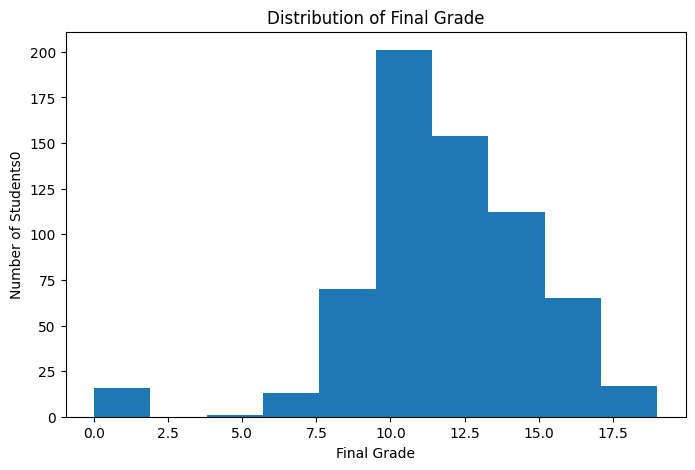

In [46]:
plt.figure(figsize=(8,5))
plt.figure(figsize=(8,5))
plt.hist(df["G3"], bins=10)
plt.xlabel("Final Grade")
plt.ylabel("Number of Students0")
plt.title("Distribution of Final Grade")
plt.show()

In [47]:
df.groupby("sex")["G3"].mean()

,G3
sex,
F,12.253264
M,11.406015


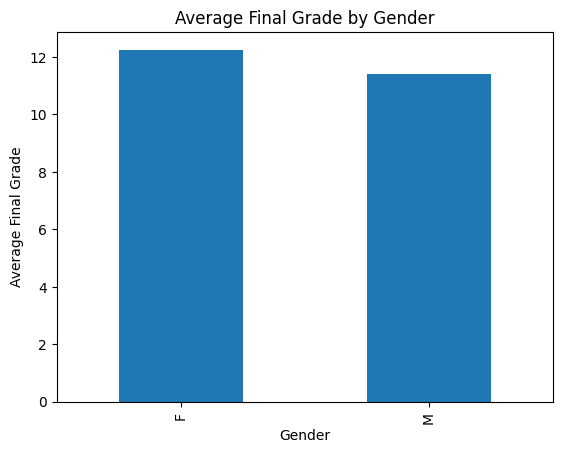

In [48]:
df.groupby("sex")["G3"].mean().plot(kind="bar")
plt.xlabel("Gender")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Gender")
plt.show()


In [49]:
df.groupby("studytime")["G3"].mean

<bound method GroupBy.mean of <pandas.core.groupby.generic.SeriesGroupBy object at 0x7904a6ee5940>>

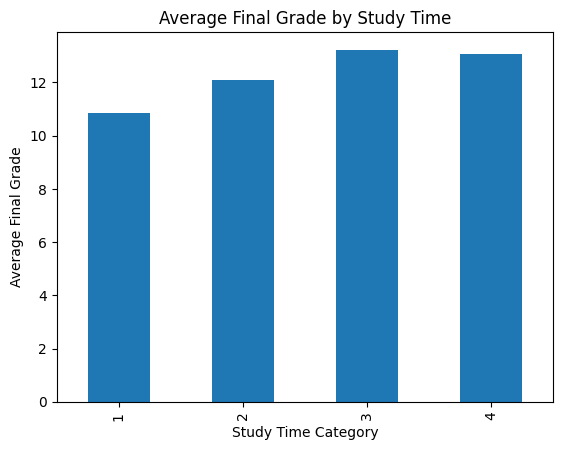

In [51]:
df.groupby("studytime")["G3"].mean().plot(kind="bar")
plt.xlabel("Study Time Category")
plt.ylabel("Average Final Grade")
plt.title("Average Final Grade by Study Time")
plt.show()


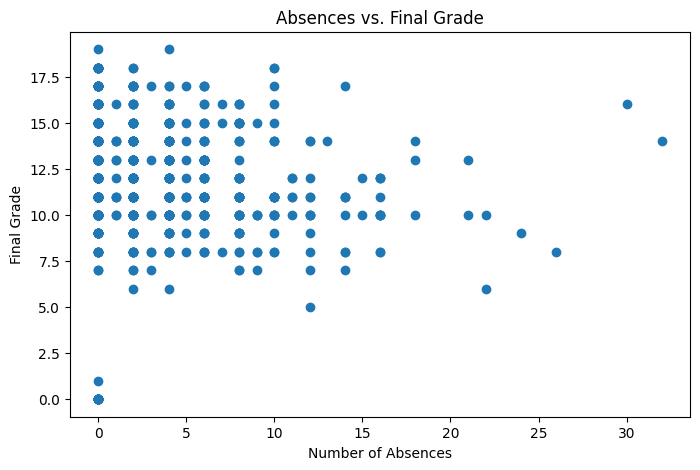

In [54]:
plt.figure(figsize=(8,5))
plt.scatter(df["absences"], df["G3"])
plt.xlabel("Number of Absences")
plt.ylabel("Final Grade")
plt.title("Absences vs. Final Grade")
plt.show()

In [56]:
print(df["absences"].corr(df["G3"]))

-0.0913790564387561


In [57]:
df["pass"] = (df["G3"] >= 10).astype(int)

In [59]:
print(df["pass"].value_counts())

pass
1    549
0    100
Name: count, dtype: int64


In [60]:
features = [
    "age",
    "studytime",
    "failures",
    "absences",
    "G1",
    "G2"
]

x = df[features]
y = df["pass"]

In [63]:
X_train, X_test, y_train, y_test = train_test_split(

  x,
  y,
  test_size = 0.20,
  random_state = 42,
  stratify=y

)



In [64]:
model=DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=42)

In [65]:
y_pred = model.predict(X_test)
print(y_pred)

[1 1 1 1 1 0 0 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 1 1 1
 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 1 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 1 1 0
 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1]


In [66]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9230769230769231


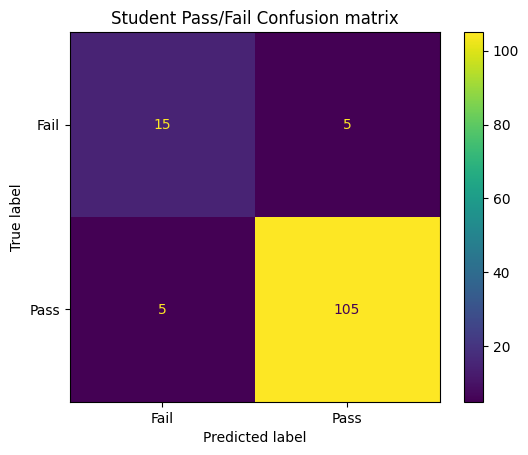

In [67]:

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fail", "Pass"]
)

disp.plot()

plt.title("Student Pass/Fail Confusion matrix")
plt.show()

In [69]:
results = X_test.copy()

results["Actual"] = y_test
results["Predicted"] = y_pred

results.head(10)

,age,studytime,failures,absences,G1,G2,Actual,Predicted
28,16,2,0,2,12,12,1,1
124,16,2,0,0,12,11,1,1
135,16,1,0,12,15,13,1,1
641,18,3,0,0,14,17,1,1
552,19,2,2,2,9,9,1,1
570,16,1,0,6,7,8,0,0
502,17,4,1,2,10,8,0,0
410,17,2,0,0,13,17,1,1
596,17,2,0,0,17,18,1,1
324,18,1,0,10,10,10,1,1


In [70]:
results["Risk"] = results["Predicted"].map({
    0: "At Risk",
    1: "Likely to Pass"
})

results.head(10)

,age,studytime,failures,absences,G1,G2,Actual,Predicted,Risk
28,16,2,0,2,12,12,1,1,Likely to Pass
124,16,2,0,0,12,11,1,1,Likely to Pass
135,16,1,0,12,15,13,1,1,Likely to Pass
641,18,3,0,0,14,17,1,1,Likely to Pass
552,19,2,2,2,9,9,1,1,Likely to Pass
570,16,1,0,6,7,8,0,0,At Risk
502,17,4,1,2,10,8,0,0,At Risk
410,17,2,0,0,13,17,1,1,Likely to Pass
596,17,2,0,0,17,18,1,1,Likely to Pass
324,18,1,0,10,10,10,1,1,Likely to Pass


In [71]:
results["Recommendation"]=results["Predicted"].map({
    0: "Prioritize for academic intervention",
    1: "Continue regular monitoring"
})

results.head(10)

,age,studytime,failures,absences,G1,G2,Actual,Predicted,Risk,Recommendation
28,16,2,0,2,12,12,1,1,Likely to Pass,Continue regular monitoring
124,16,2,0,0,12,11,1,1,Likely to Pass,Continue regular monitoring
135,16,1,0,12,15,13,1,1,Likely to Pass,Continue regular monitoring
641,18,3,0,0,14,17,1,1,Likely to Pass,Continue regular monitoring
552,19,2,2,2,9,9,1,1,Likely to Pass,Continue regular monitoring
570,16,1,0,6,7,8,0,0,At Risk,Prioritize for academic intervention
502,17,4,1,2,10,8,0,0,At Risk,Prioritize for academic intervention
410,17,2,0,0,13,17,1,1,Likely to Pass,Continue regular monitoring
596,17,2,0,0,17,18,1,1,Likely to Pass,Continue regular monitoring
324,18,1,0,10,10,10,1,1,Likely to Pass,Continue regular monitoring


In [72]:
probabilities = model.predict_proba(X_test)

results["Probability_of_Failing"] = probabilities[:,0]

results.sort_values(
    "Probability_of_Failing",
    ascending=False
).head(20)

,age,studytime,failures,absences,G1,G2,Actual,Predicted,Risk,Recommendation,Probability_of_Failing
626,18,2,0,0,7,5,0,0,At Risk,Prioritize for academic intervention,1.000000
570,16,1,0,6,7,8,0,0,At Risk,Prioritize for academic intervention,1.000000
567,18,1,1,0,4,0,0,0,At Risk,Prioritize for academic intervention,1.000000
255,18,1,1,14,8,7,0,0,At Risk,Prioritize for academic intervention,1.000000
175,17,2,2,4,7,6,0,0,At Risk,Prioritize for academic intervention,1.000000
603,18,2,0,0,5,0,0,0,At Risk,Prioritize for academic intervention,1.000000
500,17,1,1,12,6,7,0,0,At Risk,Prioritize for academic intervention,1.000000
578,17,2,1,4,8,9,1,0,At Risk,Prioritize for academic intervention,0.888889
642,17,2,0,0,6,9,1,0,At Risk,Prioritize for academic intervention,0.888889
443,15,2,0,7,7,9,0,0,At Risk,Prioritize for academic intervention,0.888889
